In [ ]:
# Fund Performance Analytics

This notebook performs fund performance analysis on mutual fund schemes.

## Tasks Completed
- Load processed datasets
- Compute Daily Returns
- Validate Daily Return Distribution
- Calculate CAGR from NAV history
- Create Fund Scorecard
- Rank Funds
- Export Alpha-Beta table
- Generate Benchmark Comparison Chart

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

print("NAV Shape :", nav.shape)
print("Performance Shape :", performance.shape)

nav.head()

NAV Shape : (46000, 3)
Performance Shape : (40, 19)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

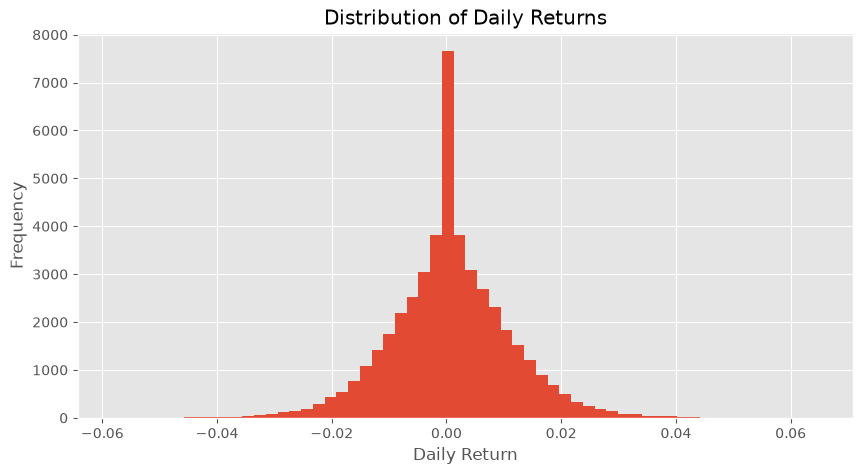

In [5]:
plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=60
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [6]:
def calculate_cagr(group):

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    days = (
        group.iloc[-1]["date"]
        -
        group.iloc[0]["date"]
    ).days

    years = days / 365.25

    if years <= 0:
        return np.nan

    return ((end_nav/start_nav)**(1/years))-1

In [7]:
cagr = (
    nav.groupby("amfi_code")
       .apply(calculate_cagr)
       .reset_index(name="calculated_cagr")
)

cagr.head()

,amfi_code,calculated_cagr
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


In [8]:
performance = performance.merge(
    cagr,
    on="amfi_code",
    how="left"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,calculated_cagr
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,0.258047
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.215242
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,0.324235
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,0.020545
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,0.058894


In [9]:
score = performance.copy()

score["return_rank"] = (
    score["return_3yr_pct"]
    .rank(ascending=False)
)

score["sharpe_rank"] = (
    score["sharpe_ratio"]
    .rank(ascending=False)
)

score["alpha_rank"] = (
    score["alpha"]
    .rank(ascending=False)
)

score["expense_rank"] = (
    score["expense_ratio_pct"]
    .rank()
)

score["drawdown_rank"] = (
    score["max_drawdown_pct"]
    .abs()
    .rank()
)

In [10]:
score["fund_score"] = (

      0.30 * score["return_rank"]

    + 0.25 * score["sharpe_rank"]

    + 0.20 * score["alpha_rank"]

    + 0.15 * score["expense_rank"]

    + 0.10 * score["drawdown_rank"]

)

In [11]:
score = score.sort_values(
    "fund_score"
)

score["overall_rank"] = range(
    1,
    len(score)+1
)

score.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,morningstar_rating,risk_grade,calculated_cagr,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,overall_rank
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,5,Moderately High,0.309075,11.0,12.0,3.5,22.0,20.0,12.300,1
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,5,Very High,0.324235,1.0,18.0,20.0,21.0,8.0,12.750,2
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,5,Low,0.072375,35.0,1.0,3.5,7.0,3.0,12.800,3
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,3,Low,0.044582,36.0,4.0,1.0,2.0,6.0,12.900,4
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,4,High,0.067015,7.0,15.0,2.0,33.0,25.0,13.700,5
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,4,Very High,0.020545,2.0,19.5,22.5,5.5,30.0,13.800,6
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,5,Moderate,0.309741,17.0,7.5,12.0,23.0,15.0,14.325,7
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,5,Very High,0.079388,3.0,24.5,5.0,28.5,27.0,15.000,8
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,3,Low,0.069153,37.0,2.0,14.0,3.0,5.0,15.350,9
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,...,5,Moderately High,0.168411,13.0,15.0,8.0,39.5,7.0,15.875,10


In [12]:
score[
[
"overall_rank",
"scheme_name",
"return_3yr_pct",
"sharpe_ratio",
"alpha",
"fund_score"
]
].head(10)

,overall_rank,scheme_name,return_3yr_pct,sharpe_ratio,alpha,fund_score
22,1,Kotak Flexicap Fund - Regular - Growth,15.65,0.98,1.85,12.300
2,2,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.23,12.750
14,3,ICICI Pru Liquid Fund - Regular - Growth,7.68,7.68,1.85,12.800
9,4,HDFC Short Term Debt Fund - Regular - Growth,7.37,1.84,1.98,12.900
21,5,Kotak Emerging Equity Fund - Regular - Growth,18.23,0.96,1.91,13.700
3,6,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,1.13,13.800
34,7,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.06,1.62,14.325
29,8,ABSL Small Cap Fund - Regular - Growth,22.38,0.90,1.84,15.000
23,9,Kotak Liquid Fund - Regular - Growth,6.18,6.18,1.52,15.350
33,10,UTI Flexi Cap Fund - Regular - Growth,15.34,0.96,1.79,15.875


In [13]:
score.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [14]:
alpha_beta = score[
[
"scheme_name",
"alpha",
"beta"
]
]

alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


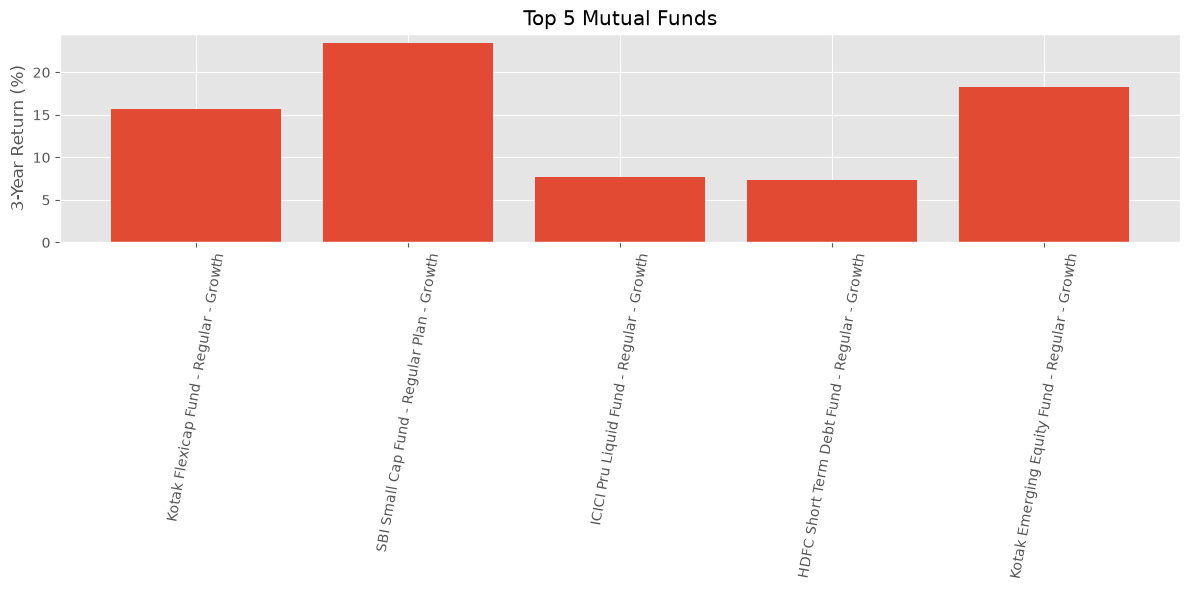

In [15]:
top5 = (
    score.sort_values("overall_rank")
         .head(5)
)

plt.figure(figsize=(12,6))

plt.bar(
    top5["scheme_name"],
    top5["return_3yr_pct"]
)

plt.xticks(rotation=80)

plt.ylabel("3-Year Return (%)")

plt.title("Top 5 Mutual Funds")

plt.tight_layout()

plt.savefig(
    "benchmark_comparison.png",
    dpi=300
)

plt.show()

In [16]:
print("="*50)

print("Total Funds :", len(score))

print("Top Ranked Fund")

print(score.iloc[0]["scheme_name"])

print("Fund Score :", round(score.iloc[0]["fund_score"],2))

print("="*50)

Total Funds : 40
Top Ranked Fund
Kotak Flexicap Fund - Regular - Growth
Fund Score : 12.3
